## Milestone 1: Data Preparation & Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from math import sqrt
from sklearn.svm import SVR
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from category_encoders import BinaryEncoder, TargetEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
# Load and Merge Training/Test Datasets
insur_prem = pd.read_csv('Insurance Premium Prediction Dataset.csv')
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')
combined_data = pd.concat([train_data, test_data], ignore_index=True)

In [3]:
# Implement Custom Imputation Strategies for Missing Values
numerics = [
    'Age',
    'Annual Income',
    'Number of Dependents',
    'Health Score',
    'Previous Claims',
    'Vehicle Age',
    'Credit Score',
    'Insurance Duration',
]

categorical = [
    'Gender',
    'Marital Status',
    'Education Level',
    'Occupation',
    'Location',
    'Policy Type',
    'Customer Feedback',
    'Smoking Status',
    'Exercise Frequency',
    'Property Type'
]
for col in numerics:
    combined_data[col] = combined_data[col].fillna(combined_data[col].median())

for col in categorical:
    combined_data[col] = combined_data[col].fillna(combined_data[col].mode()[0])

combined_data = combined_data.dropna(subset=['Premium Amount'])

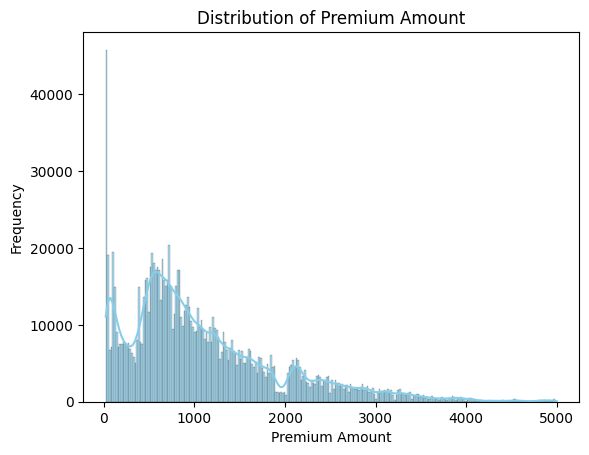

In [4]:
# Perform exploratory data analysis using different data visualizations
# Histogram of Premium Amount
sns.histplot(combined_data['Premium Amount'], kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Premium Amount')
plt.xlabel('Premium Amount')
plt.ylabel('Frequency')
plt.show()

Text(0.5, 0, 'Log(1 + Premium Amount)')

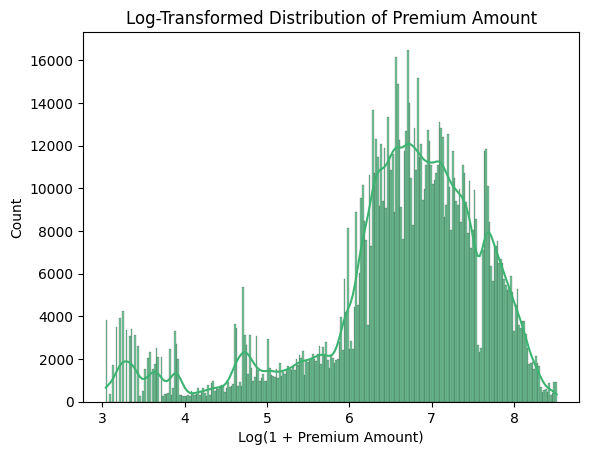

In [5]:
# Perform exploratory data analysis using different data visualizations
# Histogram of Log Premium Amount
combined_data['Log Premium'] = np.log1p(combined_data['Premium Amount'])
sns.histplot(combined_data['Log Premium'], kde=True, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.title('Log-Transformed Distribution of Premium Amount')
plt.xlabel('Log(1 + Premium Amount)')

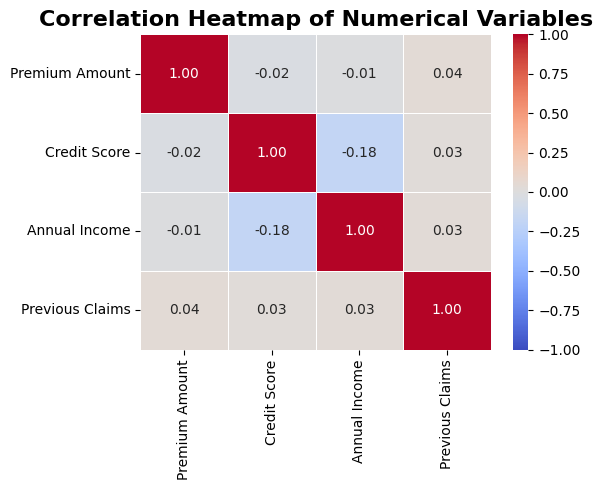

In [6]:
# Perform exploratory data analysis using different data visualizations
# Heatmap of Numerical Categories Correlations
selected = ['Premium Amount', 'Credit Score', 'Annual Income', 'Previous Claims']
correlation_matrix = combined_data[selected].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

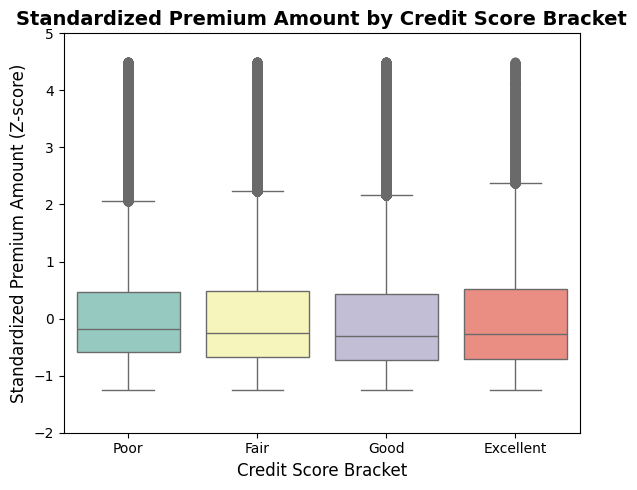

In [7]:
# Perform exploratory data analysis using different data visualizations
# Boxplot of Credit Score and Premium Amount
combined_data['Credit Score Bin'] = pd.cut(
    combined_data['Credit Score'],
    bins=[0, 400, 600, 800, 1000],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)
scaler = StandardScaler()
combined_data['Premium Scaled'] = scaler.fit_transform(combined_data[['Premium Amount']])
plt.figure(figsize=(6, 5))
sns.boxplot(x='Credit Score Bin', y='Premium Scaled', data=combined_data, hue='Credit Score Bin', palette='Set3')
plt.title('Standardized Premium Amount by Credit Score Bracket', fontsize=14, fontweight='bold')
plt.xlabel('Credit Score Bracket', fontsize=12)
plt.ylabel('Standardized Premium Amount (Z-score)', fontsize=12)
plt.ylim(-2, 5)
plt.tight_layout()
plt.show()

In [8]:
# Split the data into training and validation sets (80/20 ratio)
X = combined_data.drop(columns=['Premium Amount'])
y = combined_data['Premium Amount']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data size: {X_train.shape[0]} rows")
print(f"Validation data size: {X_val.shape[0]} rows")

Training data size: 960000 rows
Validation data size: 240000 rows


## Milestone 2: Model Development & Tuning

In [9]:
# Implement an advanced preprocessing pipeline
binary_cols = ['Gender', 'Smoking Status']
ordinal_cols = ['Customer Feedback']
target_encoded_cols = ['Occupation', 'Location', 'Policy Type', 'Property Type']
exclude_cols = binary_cols + ordinal_cols + target_encoded_cols + ['id', 'Policy Start Date']
numeric_cols = ['Age', 'Annual Income', 'Number of Dependents', 'Health Score', 
            'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('bin', ce.BinaryEncoder(), binary_cols),
    ('ord', OrdinalEncoder(), ordinal_cols),
    ('target', ce.TargetEncoder(), target_encoded_cols)
])

model_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [10]:
# Train a baseline regressor model (try different regression models)
best_model = None
best_model_name = None
best_rmse = float('inf')

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('regressor', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    rmse = sqrt(mean_squared_error(y_val, y_pred))
    print(f'{name}: RMSE = {rmse:.2f}')
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_model_name = name
        best_model = pipeline

# Evaluate model performance using RMSE
print(f'\nBest model: {best_model_name} with RMSE = {best_rmse:.2f}')

Linear Regression: RMSE = 863.34
Ridge Regression: RMSE = 863.34
Lasso Regression: RMSE = 863.33
Decision Tree: RMSE = 1236.76
Random Forest: RMSE = 857.34
Gradient Boosting: RMSE = 853.57

Best model: Gradient Boosting with RMSE = 853.57


## Milestone 3: Kaggle Competition Submission

In [14]:
# Save Submission and Submit
for col in categorical:
    test_data[col] = test_data[col].fillna(combined_data[col].mode()[0])

for col in numerics:
    test_data[col] = test_data[col].fillna(combined_data[col].median())

X_test = test_data.drop(columns=['Premium Amount'], errors='ignore')

test_preds = best_model.predict(X_test)

submission = pd.DataFrame({
    'id': test_data['id'],
    'Premium Amount': test_preds
})

submission.to_csv('submission.csv', index=False)
print("Predictions saved to 'submission.csv'.")

Predictions saved to 'submission.csv'.
